# LÓGICA DIFUSA | Sistema de Inferencia difusa de Sugeno

1. Crear un modelo de Sugeno del comportamiento de un diodo, para lo cual se ha medido la tensión en sus bornes y la corriente que lo atraviesa. Los datos obtenidos se encuentran en el archivo diodo.txt. El modelo logrado deberá tener no más de dos reglas.

c:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\subpr

--- 0.13918852806091309 seconds ---
nivel acti
[[0.47965226 0.0736554 ]
 [0.7528453  0.18901104]
 [0.904623   0.31519887]
 [0.9574614  0.3930123 ]
 [0.9899732  0.47871393]
 [0.9999404  0.56963223]
 [0.986673   0.6621577 ]
 [0.986673   0.6621577 ]
 [0.9510883  0.75192904]
 [0.9510883  0.75192904]
 [0.9141427  0.81056434]
 [0.895606   0.83414346]
 [0.875601   0.8566045 ]
 [0.84684527 0.88459677]
 [0.8238754  0.90396816]
 [0.79984415 0.9218225 ]
 [0.77488196 0.9380539 ]
 [0.7491213  0.95256525]
 [0.722695   0.9652682 ]
 [0.70477325 0.97269326]
 [0.895606   0.83414346]
 [0.8159765  0.91009355]
 [0.7577887  0.947925  ]
 [0.68665373 0.97925943]
 [0.63148975 0.9936353 ]
 [0.5758911  0.9997738 ]
 [0.5298997  0.9984791 ]
 [0.4847404  0.9913759 ]
 [0.44950476 0.98159105]
 [0.42372802 0.97192746]
 [0.39036414 0.9560568 ]
 [0.36617696 0.94200915]
 [0.3427666  0.92621744]
 [0.3201786  0.9087765 ]
 [0.30559573 0.896284  ]
 [0.28445816 0.8763287 ]
 [0.27086833 0.8622644 ]]
sumMu
[[0.55330765]
 [0.941

<Axes: xlabel='V', ylabel='I'>

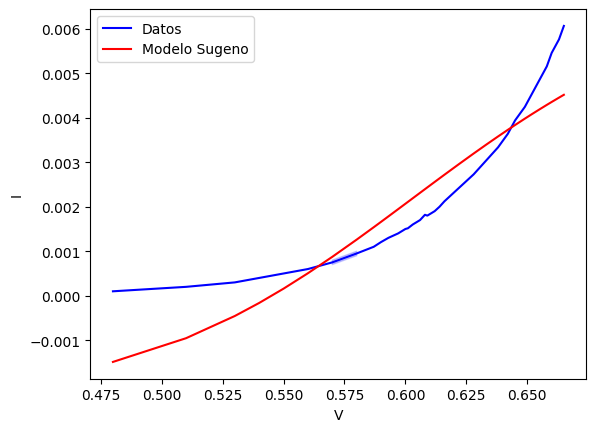

In [1]:
import pandas as pd
import seaborn as sb
from utils.gen_fis import fis
from sklearn.cluster import KMeans
import numpy.typing as npt
import numpy as np

K = 2
diodo = pd.read_table("diodo.txt", sep="\t", header=0, names=["V", "I"])

def kmeans() -> tuple[npt.NDArray[np.intp], npt.NDArray[np.float64]]:
    kmeans = KMeans(n_clusters=K, random_state=0).fit(diodo.to_numpy())
    return kmeans.labels_, kmeans.cluster_centers_

fis_diodo = fis()
fis_diodo.genfis(diodo.to_numpy(), kmeans)
r = fis_diodo.evalfis(diodo.to_numpy()[:, 0])
grafico = diodo.assign(r=pd.Series(r).to_numpy().ravel())

sb.lineplot(data=grafico, x="V", y="I", color="blue", label="Datos")
sb.lineplot(data=grafico, x="V", y="r", color="red", label="Modelo Sugeno")